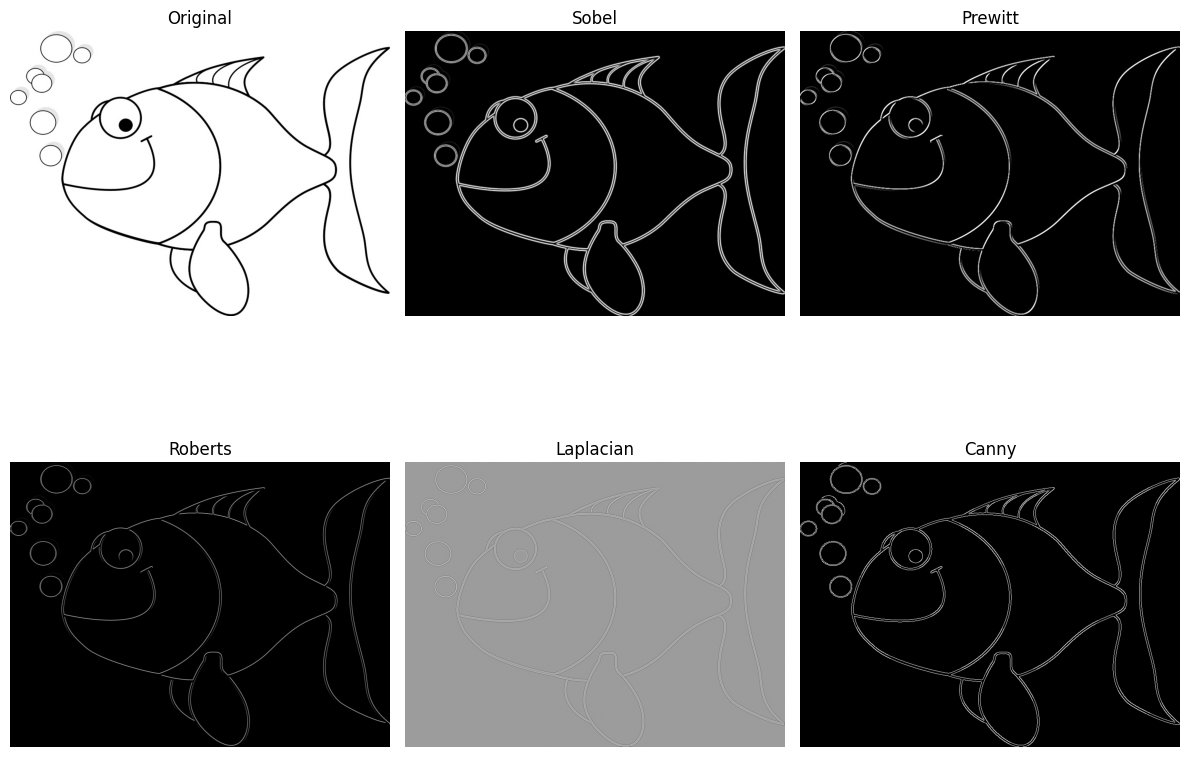

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
image = cv2.imread('Fish.jpg')  # replace with your path
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# ---------------- SOBEL ----------------
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)
sobel = cv2.magnitude(sobel_x, sobel_y)

# ---------------- PREWITT ----------------
prewitt_x = np.array([[1, 0, -1],
                      [1, 0, -1],
                      [1, 0, -1]])

prewitt_y = np.array([[1, 1, 1],
                      [0, 0, 0],
                      [-1, -1, -1]])

prewitt_x_edge = cv2.filter2D(gray, -1, prewitt_x)
prewitt_y_edge = cv2.filter2D(gray, -1, prewitt_y)
prewitt = cv2.magnitude(prewitt_x_edge.astype(np.float32),
                        prewitt_y_edge.astype(np.float32))

# ---------------- ROBERTS ----------------
roberts_x = np.array([[1, 0],
                      [0, -1]])

roberts_y = np.array([[0, 1],
                      [-1, 0]])

roberts_x_edge = cv2.filter2D(gray, -1, roberts_x)
roberts_y_edge = cv2.filter2D(gray, -1, roberts_y)
roberts = cv2.magnitude(roberts_x_edge.astype(np.float32),
                        roberts_y_edge.astype(np.float32))

# ---------------- LAPLACIAN ----------------
laplacian = cv2.Laplacian(gray, cv2.CV_64F)

# ---------------- CANNY ----------------
canny = cv2.Canny(gray, 50, 150)

# ---------------- DISPLAY ----------------
plt.figure(figsize=(12, 10))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(sobel, cmap='gray')
plt.title("Sobel")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(prewitt, cmap='gray')
plt.title("Prewitt")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(roberts, cmap='gray')
plt.title("Roberts")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(laplacian, cmap='gray')
plt.title("Laplacian")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(canny, cmap='gray')
plt.title("Canny")
plt.axis("off")

plt.tight_layout()
plt.show()